# Customer 360 EDA — Part 1: Dataset Discovery & Data Quality

This is **Part 1 of 3** of the Exploratory Data Analysis (EDA) for the **Customer 360** multi-source dataset.

> The requirements for this EDA are defined in [`docs/eda-requirements.md`](../docs/eda-requirements.md).

The raw data lives in a **single Excel workbook** (`data/raw/DATASET.xlsx`) that contains **16 sheets** — one sheet per logical dataset/source. A companion file (`data/raw/METADATA.xlsx`) documents each sheet, column, relation, and data-quality note.

**This notebook covers:**
1. Environment & imports
2. Dataset discovery (load all sheets from the single workbook)
3. Dataset overview / summary table
4. Schema profiling
5. Data quality (missingness, duplicates, invalid values)

> **Important rules observed:** we inspect the *actual* data before drawing conclusions; we never fabricate statistics; we preserve raw data; we distinguish missing from zero; we do **not** perform entity resolution here (that is Part 2's focus and the future modeling stage).


## 1. Environment & imports

We use **pandas** (dataset fits comfortably in memory; the full workbook is ~50k rows max per sheet) and **matplotlib** for focused visualizations. `openpyxl` is required to read the Excel workbook.


In [1]:
import os
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
def _find_repo_root():
    p = Path.cwd()
    for _ in range(8):
        if (p / "data" / "raw" / "DATASET.xlsx").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Could not locate repo root (data/raw/DATASET.xlsx) from " + str(Path.cwd()))

REPO = _find_repo_root()
RAW = REPO / "data" / "raw"
DATASET_FILE = RAW / "DATASET.xlsx"
METADATA_FILE = RAW / "METADATA.xlsx"
OUT_DIR = REPO / "notebooks" / "eda" / "output"


assert DATASET_FILE.exists(), f"Dataset not found: {DATASET_FILE}"
print("Dataset file :", DATASET_FILE)
print("Metadata file:", METADATA_FILE)
print("Output dir   :", OUT_DIR)


Dataset file : /home/mhseddighi/Projects/b2b-ai-crm/data/raw/DATASET.xlsx
Metadata file: /home/mhseddighi/Projects/b2b-ai-crm/data/raw/METADATA.xlsx
Output dir   : /home/mhseddighi/Projects/b2b-ai-crm/notebooks/eda/output


## 2. Dataset discovery

The dataset is provided as **one Excel workbook with many sheets** instead of multiple files. We load every sheet into a dictionary `{sheet_name: DataFrame}` and treat each sheet as its own dataset/source.

Per the requirements we report, for every sheet: name, type, rows, columns, dtypes, and a few sample records.


In [2]:
# ------------------------------------------------------------------
# Load all sheets from the single Excel workbook
# ------------------------------------------------------------------
def load_workbook(path: Path):
    xl = pd.ExcelFile(path)
    return {name: xl.parse(name) for name in xl.sheet_names}

DATA = load_workbook(DATASET_FILE)
print("Loaded sheets:", list(DATA.keys()))
print("Total sheets:", len(DATA))


Loaded sheets: ['مشتریان', 'محصولات', 'فاکتورها', 'فروش', 'اجزای_هزینه_تحقق', 'وصول', 'شکایات', 'اتصال_شکایت', 'تعاملات_CRM', 'درخواست_توسعه', 'کیفیت_لات', 'همبافت_لات', 'آفرها', 'سهم_سبد', 'سیگنال_بازار', 'برآورد_هزینه_ماهانه']
Total sheets: 16


In [3]:
# Per-sheet quick facts
summary = []
for name, df in DATA.items():
    summary.append({
        "Sheet": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "DuplicateRows": int(df.duplicated().sum()),
        "NumericCols": int(df.select_dtypes(include=np.number).shape[1]),
        "TextCols": int(df.select_dtypes(include="object").shape[1]),
        "HasCustomerID": "Customer_ID" in df.columns,
    })
summary_df = pd.DataFrame(summary)
summary_df


,Sheet,Rows,Columns,DuplicateRows,NumericCols,TextCols,HasCustomerID
0,مشتریان,644,9,0,2,7,True
1,محصولات,646,8,0,0,8,False
2,فاکتورها,14423,7,0,0,7,True
3,فروش,52987,22,0,5,17,True
4,اجزای_هزینه_تحقق,17081,10,0,3,7,False
5,وصول,15652,11,0,2,9,True
6,شکایات,520,15,0,0,15,True
7,اتصال_شکایت,597,13,0,3,10,True
8,تعاملات_CRM,4184,13,0,1,12,True
9,درخواست_توسعه,800,12,0,0,12,True


In [4]:
# Memory usage per sheet (practical for a single workbook)
mem = []
for name, df in DATA.items():
    mem.append({"Sheet": name, "Memory_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2)})
mem_df = pd.DataFrame(mem)
mem_df


,Sheet,Memory_MB
0,مشتریان,0.28
1,محصولات,0.36
2,فاکتورها,5.70
3,فروش,55.39
4,اجزای_هزینه_تحقق,7.65
5,وصول,8.92
6,شکایات,0.90
7,اتصال_شکایت,0.38
8,تعاملات_CRM,5.23
9,درخواست_توسعه,1.00


In [5]:
# Show column names of every sheet (as-is, from the actual file)
for name, df in DATA.items():
    print(f"--- {name} ({df.shape[0]} x {df.shape[1]}) ---")
    print(list(df.columns))
    print()


--- مشتریان (644 x 9) ---
['Customer_ID', 'Location_ID', 'Customer_Segment', 'Relationship_Start_Date', 'Credit_Limit', 'Payment_Terms_Days', 'Customer_Status', 'Source_System', 'Sales_Rep_ID']

--- محصولات (646 x 8) ---
['Product_ID', 'شرح کالا', 'Quality_Class_ID', 'دسته بندی براقیت', 'گروه کالا', 'گروه رنگ', 'زیرگروه کالا', 'Source_System']

--- فاکتورها (14423 x 7) ---
['شماره فاکتور', 'تاریخ', 'Customer_ID', 'ماه', 'سال', 'Available_At', 'Source_System']

--- فروش (52987 x 22) ---
['ردیف فاکتور', 'تاریخ', 'نوع پرداخت', 'Customer_ID', 'Product_ID', 'Quality_Class_ID', 'مقدار', 'قیمت فی فروش', 'مبلغ کل', 'شماره فاکتور', 'ماه', 'سال', 'دسته بندی براقیت', 'گروه کالا', 'گروه رنگ', 'زیرگروه کالا', 'Sales_Line_ID', 'Lot_ID', 'Hembaft_ID', 'Hembaft_Lot_Key', 'Available_At', 'Source_System']

--- اجزای_هزینه_تحقق (17081 x 10) ---
['Cost_Record_ID', 'Sales_Line_ID', 'شماره فاکتور', 'Product_ID', 'هزینه کل به ازای واحد', 'مقدار برگشتی', 'مبلغ برگشتی', 'Cost_Close_Date', 'Available_At', 'Sour

### 2.1 Summary table

| Dataset (sheet) | Rows | Columns | Likely domain |
|---|---|---|---|


In [6]:
# Print a human-readable summary table
def fmt_domain(name):
    domains = {
        "مشتریان": "Customer master",
        "محصولات": "Product master",
        "فاکتورها": "Invoice header",
        "فروش": "Sales lines (orders)",
        "اجزای_هزینه_تحقق": "Realized cost per sales line",
        "وصول": "Collections / receivable events",
        "شکایات": "Complaints",
        "اتصال_شکایت": "Complaint <-> Sales bridge",
        "تعاملات_CRM": "CRM interactions",
        "درخواست_توسعه": "Product development requests",
        "کیفیت_لات": "Lab / lot quality measurements",
        "همبافت_لات": "Hembaft <-> Lot mapping",
        "آفرها": "Commercial offers",
        "سهم_سبد": "Customer wallet-share estimates",
        "سیگنال_بازار": "Market signals",
        "برآورد_هزینه_ماهانه": "Monthly estimated cost (product-month)",
    }
    return domains.get(name, "?")


In [7]:
summary_tbl = summary_df.copy()
summary_tbl["LikelyDomain"] = summary_tbl["Sheet"].map(fmt_domain)
summary_tbl


,Sheet,Rows,Columns,DuplicateRows,NumericCols,TextCols,HasCustomerID,LikelyDomain
0,مشتریان,644,9,0,2,7,True,Customer master
1,محصولات,646,8,0,0,8,False,Product master
2,فاکتورها,14423,7,0,0,7,True,Invoice header
3,فروش,52987,22,0,5,17,True,Sales lines (orders)
4,اجزای_هزینه_تحقق,17081,10,0,3,7,False,Realized cost per sales line
5,وصول,15652,11,0,2,9,True,Collections / receivable events
6,شکایات,520,15,0,0,15,True,Complaints
7,اتصال_شکایت,597,13,0,3,10,True,Complaint <-> Sales bridge
8,تعاملات_CRM,4184,13,0,1,12,True,CRM interactions
9,درخواست_توسعه,800,12,0,0,12,True,Product development requests


## 3. Schema profiling

For every sheet we build a **column-level profiling table**:

| Column | Type | Missing % | Unique | Unique % | Example | Likely meaning |
|---|---|---|---|---|---|---|


In [8]:
# ------------------------------------------------------------------
# Column-level profiling for one sheet
# ------------------------------------------------------------------
def profile_columns(df, sheet_name):
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        missing = int(s.isna().sum())
        missing_pct = missing / n * 100
        nuniq = int(s.nunique(dropna=True))
        uniq_pct = nuniq / n * 100
        if s.dtype == "object":
            example = s.dropna().iloc[0] if s.notna().any() else None
            ex = str(example)[:40]
        else:
            ex = s.dropna().iloc[0] if s.notna().any() else None
        rows.append({
            "Sheet": sheet_name, "Column": col, "Dtype": str(s.dtype),
            "Missing%": round(missing_pct, 2), "Unique": nuniq,
            "Unique%": round(uniq_pct, 2), "Example": ex,
        })
    return pd.DataFrame(rows)

profiles = pd.concat([profile_columns(df, name) for name, df in DATA.items()], ignore_index=True)
print("Total profiled columns:", len(profiles))

profiles


Total profiled columns: 186


,Sheet,Column,Dtype,Missing%,Unique,Unique%,Example
0,مشتریان,Customer_ID,str,0.0,644,100.00,C_009817
1,مشتریان,Location_ID,str,0.0,16,2.48,LOC-012
2,مشتریان,Customer_Segment,str,0.0,3,0.47,B
3,مشتریان,Relationship_Start_Date,str,0.0,138,21.43,2020-07-20
4,مشتریان,Credit_Limit,int64,0.0,475,73.76,35000
...,...,...,...,...,...,...,...
181,برآورد_هزینه_ماهانه,Month_Key,str,0.0,40,0.47,2019-12
182,برآورد_هزینه_ماهانه,Available_At,str,0.0,40,0.47,2019-12-01
183,برآورد_هزینه_ماهانه,هزینه کل برآوردی به ازای واحد,float64,0.0,6797,79.53,88.56
184,برآورد_هزینه_ماهانه,Estimate_Version,str,0.0,1,0.01,PLAN_V1


In [9]:
# Show profiling only for the two masters + sales + complaints for readability
profiles[profiles.Sheet.isin(["مشتریان", "محصولات", "فروش", "شکایات", "تعاملات_CRM"])]


,Sheet,Column,Dtype,Missing%,Unique,Unique%,Example
0,مشتریان,Customer_ID,str,0.0,644,100.00,C_009817
1,مشتریان,Location_ID,str,0.0,16,2.48,LOC-012
2,مشتریان,Customer_Segment,str,0.0,3,0.47,B
3,مشتریان,Relationship_Start_Date,str,0.0,138,21.43,2020-07-20
4,مشتریان,Credit_Limit,int64,0.0,475,73.76,35000
...,...,...,...,...,...,...,...
103,تعاملات_CRM,Summary_Text,str,0.0,2462,58.84,مشتری برنامه تقریبی خرید دوره بعد را اعلام کرد. اقدام بع...
104,تعاملات_CRM,Next_Action,str,0.0,5,0.12,جلسه قیمت
105,تعاملات_CRM,Record_Status,str,0.0,2,0.05,ثبت اولیه
106,تعاملات_CRM,Source_System,str,0.0,1,0.02,CRM_ACTIVITIES


### Automatically flag important columns

The requirements list columns that may matter for identity and analysis (customer_id, name, email, phone, date, product, etc.). We detect similar fields in the actual data.


In [10]:
# Flag "interesting" columns by fuzzy keyword matching
interesting_keywords = ["customer", "client", "contact", "company", "name", "email", "phone",
                        "address", "city", "industry", "product", "order", "invoice", "complaint",
                        "date", "description", "notes", "text", "comment", "status", "segment",
                        "price", "amount", "quantity", "lot", "hembaft", "rep", "cost", "channel"]
mask = profiles["Column"].str.lower().apply(
    lambda c: any(k in c.lower() for k in interesting_keywords)
)
flagged = profiles[mask].copy()
print(f"{len(flagged)} columns matched identity/analysis keywords.")
flagged[["Sheet", "Column", "Dtype", "Missing%", "Unique%", "Example"]]


65 columns matched identity/analysis keywords.


,Sheet,Column,Dtype,Missing%,Unique%,Example
0,مشتریان,Customer_ID,str,0.00,100.00,C_009817
2,مشتریان,Customer_Segment,str,0.00,0.47,B
3,مشتریان,Relationship_Start_Date,str,0.00,21.43,2020-07-20
6,مشتریان,Customer_Status,str,0.00,0.31,غیرفعال
8,مشتریان,Sales_Rep_ID,str,0.00,1.24,REP-003
...,...,...,...,...,...,...
170,سیگنال_بازار,Product_Market,str,0.00,5.38,Product_Family_06
171,سیگنال_بازار,Customer_ID,str,54.62,43.85,C_167944
173,سیگنال_بازار,Customer_Signal,str,0.00,3.08,وصول متمرکز
174,سیگنال_بازار,Price_Index,float64,0.00,92.31,109.2


## 4. Data quality — missingness

We analyze missingness per sheet and identify completely-missing, highly-incomplete, and moderate-missingness columns. We then identify rows with unusually high missingness.


In [11]:
# Missingness summary per column, across all sheets
miss = profiles[profiles["Missing%"] > 0].sort_values("Missing%", ascending=False)
print(f"{len(miss)} columns have at least some missing values.")
miss


16 columns have at least some missing values.


,Sheet,Column,Dtype,Missing%,Unique,Unique%,Example
42,فروش,Hembaft_ID,float64,99.90,48,0.09,1173910000.0
43,فروش,Hembaft_Lot_Key,str,99.90,52,0.10,HL-10FE7709AAB46FEE
124,کیفیت_لات,Hembaft_Lot_Key,str,99.77,32,0.23,HL-ECD75E7985A4AA9E
123,کیفیت_لات,Hembaft_ID,float64,99.77,29,0.21,1176610000.0
73,شکایات,Hembaft_Reference,str,92.31,38,7.31,1173910000
89,اتصال_شکایت,Hembaft_Lot_Key,str,91.29,52,8.71,HL-10FE7709AAB46FEE
87,اتصال_شکایت,Hembaft_ID,float64,91.29,48,8.04,1173910000.0
171,سیگنال_بازار,Customer_ID,str,54.62,57,43.85,C_167944
117,درخواست_توسعه,Outcome_Text,str,30.88,7,0.88,درخواست با محدودیت فنی فعلی سازگار نبود.
115,درخواست_توسعه,Decision_At,str,30.88,404,50.50,2021-06-05


In [12]:
# Classify columns by missingness severity
def classify_missing(pct):
    if pct == 0: return "none"
    if pct < 5: return "low"
    if pct < 50: return "moderate"
    if pct < 100: return "high"
    return "complete"

miss2 = profiles.copy()
miss2["Severity"] = miss2["Missing%"].apply(classify_missing)
sev_counts = miss2["Severity"].value_counts().reindex(["none","low","moderate","high","complete"])
print(sev_counts.to_string())
print()
print("Completely-missing columns (Missing% = 100):")
print(profiles[profiles["Missing%"] == 100][["Sheet","Column"]].to_string(index=False))


Severity
none        170.0
low           NaN
moderate      8.0
high          8.0
complete      NaN

Completely-missing columns (Missing% = 100):
Empty DataFrame
Columns: [Sheet, Column]
Index: []


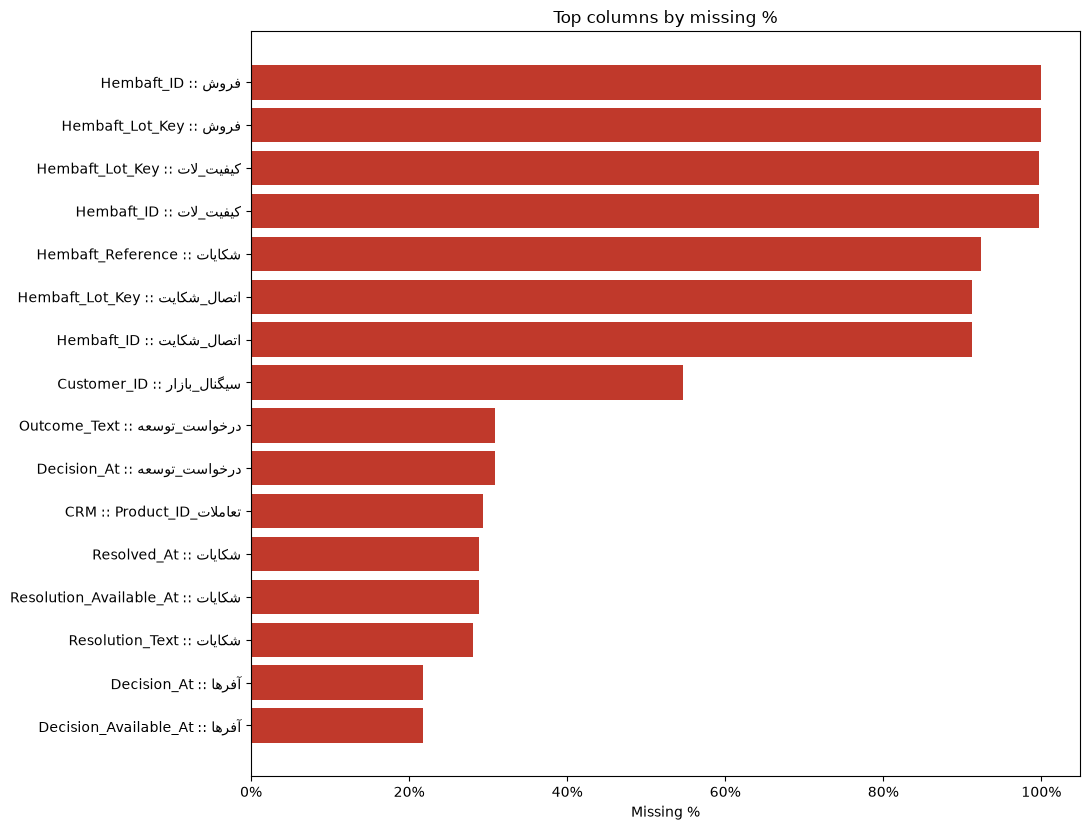

In [13]:
# Visualize missingness — only columns that actually have missing values
missing_cols = miss[miss["Missing%"] > 0]
top_missing = missing_cols.nlargest(30, "Missing%")
if len(top_missing):
    fig, ax = plt.subplots(figsize=(11, 0.4 * len(top_missing) + 2))
    labels = [f"{r.Sheet} :: {r.Column}" for r in top_missing.itertuples()]
    ax.barh(labels, top_missing["Missing%"].values, color="#c0392b")
    ax.invert_yaxis()
    ax.set_title("Top columns by missing %")
    ax.set_xlabel("Missing %")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()

    plt.show()
else:
    print("No columns with missing values across all sheets.")


In [14]:
# Rows with unusually high missingness per sheet
print("Sheets with any row missing > 50% of its columns:")
for name, df in DATA.items():
    row_miss = df.isna().sum(axis=1)
    high = (row_miss > df.shape[1] * 0.5).sum()
    if high:
        print(f"  {name}: {high} rows (>50% missing)")


Sheets with any row missing > 50% of its columns:


## 5. Data quality — duplicates

We analyze exact duplicate rows and duplicate values on key identifier columns. **Duplicates are not automatically errors** — we reason about what they may represent (multiple transactions, CRM versions, etc.).


In [15]:
# Exact duplicate rows per sheet
print("Exact duplicate rows per sheet:")
for name, df in DATA.items():
    d = int(df.duplicated().sum())
    if d:
        print(f"  {name}: {d} exact duplicate rows")


Exact duplicate rows per sheet:


In [16]:
# Duplicate IDs per sheet (primary-key-ish column)
# We use the metadata-defined grain to pick an identifier per sheet.
pk_map = {
    "مشتریان": "Customer_ID", "محصولات": "Product_ID", "فاکتورها": "شماره فاکتور",
    "فروش": "Sales_Line_ID", "اجزای_هزینه_تحقق": "Cost_Record_ID", "وصول": "Collection_ID",
    "شکایات": "Complaint_ID", "اتصال_شکایت": ["Complaint_ID","Sales_Line_ID"],
    "تعاملات_CRM": ["Interaction_ID","Record_Version"], "درخواست_توسعه": "Request_ID",
    "کیفیت_لات": "Quality_Record_ID", "همبافت_لات": "Hembaft_Lot_Key", "آفرها": "Offer_ID",
    "سهم_سبد": ["Customer_ID","Month_Key"], "سیگنال_بازار": "Week_ID",
    "برآورد_هزینه_ماهانه": "Estimate_ID",
}
print("Duplicate values on each sheet's grain/primary key:")
for name, cols in pk_map.items():
    df = DATA[name]
    cols = [cols] if isinstance(cols, str) else cols
    if all(c in df.columns for c in cols):
        dup = df.duplicated(subset=cols).sum()
        flag = "  <-- CHECK" if dup else ""
        print(f"  {name}: {dup} duplicate {cols}{flag}")


Duplicate values on each sheet's grain/primary key:
  مشتریان: 0 duplicate ['Customer_ID']
  محصولات: 0 duplicate ['Product_ID']
  فاکتورها: 0 duplicate ['شماره فاکتور']
  فروش: 0 duplicate ['Sales_Line_ID']
  اجزای_هزینه_تحقق: 0 duplicate ['Cost_Record_ID']
  وصول: 0 duplicate ['Collection_ID']
  شکایات: 0 duplicate ['Complaint_ID']
  اتصال_شکایت: 0 duplicate ['Complaint_ID', 'Sales_Line_ID']
  تعاملات_CRM: 0 duplicate ['Interaction_ID', 'Record_Version']
  درخواست_توسعه: 0 duplicate ['Request_ID']
  کیفیت_لات: 0 duplicate ['Quality_Record_ID']
  همبافت_لات: 0 duplicate ['Hembaft_Lot_Key']
  آفرها: 0 duplicate ['Offer_ID']
  سهم_سبد: 0 duplicate ['Customer_ID', 'Month_Key']
  سیگنال_بازار: 0 duplicate ['Week_ID']
  برآورد_هزینه_ماهانه: 0 duplicate ['Estimate_ID']


### Interpretation of duplicates

- **فروش (sales)**: duplicates on `Sales_Line_ID` would be errors, but complaint-linked lines were appended in the same grain (per metadata note). 
- **تعاملات_CRM**: the grain is `Interaction_ID + Record_Version` — this is intentional **versioning**, not duplication. The "latest version" rule is handled in Part 3.
- Other duplicate-rows / duplicate-IDs above indicate real quality issues to investigate before building the 360 view.

> **Conclusion (preliminary):** most sheets are clean at the row level; the main intentional "duplication" is CRM record versioning and the complaint bridge. We quantify cross-sheet overlap and entity-resolution readiness in **Part 2**.


## 6. Data quality — invalid / placeholder values

We look for placeholder values (N/A, unknown, -, null, test, 0) and inconsistent text/casing, and **report** suspicious values rather than deleting them.


In [17]:
placeholder_set = {"n/a", "na", "unknown", "-", "null", "none", "test", "؟", "nan", ""}

print("Placeholder / suspicious values in text columns (top 20 by sheet):")
found_any = False
for name, df in DATA.items():
    for col in df.select_dtypes(include="object").columns:
        vals = df[col].dropna().astype(str).str.strip().str.lower()
        bad = vals[vals.isin(placeholder_set)]
        if len(bad):
            found_any = True
            print(f"  {name} :: {col}: {len(bad)} placeholder values")
if not found_any:
    print("  (none found)")


Placeholder / suspicious values in text columns (top 20 by sheet):


  (none found)


In [18]:
# Empty-string vs null check (distinguish missing from zero/empty)
print("Columns where empty-string counts matter (non-null but empty):")
for name, df in DATA.items():
    for col in df.select_dtypes(include="object").columns:
        empt = int((df[col].astype(str).str.strip() == "").sum())
        if empt:
            print(f"  {name} :: {col}: {empt} empty strings")


Columns where empty-string counts matter (non-null but empty):


In [19]:
# Numeric sanity: negative quantities/prices where inappropriate
print("Numeric sanity checks:")
num_cols = {
    "فروش": ["مقدار", "قیمت فی فروش", "مبلغ کل"],
    "وصول": ["مبلغ وصول"],
    "اجزای_هزینه_تحقق": ["هزینه کل به ازای واحد", "مقدار برگشتی", "مبلغ برگشتی"],
    "آفرها": ["Base_Price_per_unit", "Offered_Price_per_unit"],
}
for sheet, cols in num_cols.items():
    if sheet in DATA:
        for c in cols:
            if c in DATA[sheet].columns:
                s = DATA[sheet][c]
                neg = int((s < 0).sum())
                if neg:
                    print(f"  {sheet} :: {c}: {neg} negative values")
print("  (only reported if found)")


Numeric sanity checks:
  (only reported if found)


## 7. Summary of Part 1

- **One Excel workbook, 16 sheets** — every logical source is a sheet; all customer-centric sheets share a common `Customer_ID`.
- Total rows range from **52** (همبافت_لات) to **~53k** (فروش).
- Most sheets have **0% missing**; the notable exceptions are the `Hembaft_*` linkage columns (intentionally empty for sources that lack that identifier — documented in metadata) and text/decision columns.
- **Intentional "duplicates":** CRM `Interaction_ID + Record_Version` versioning and the complaint `اتصال_شکایت` bridge.
- **No PII / contact / address columns exist** (per metadata, names, emails, phones, industries, cities were removed for privacy).

We now proceed to **Part 2: Customer Identity & Cross-Source Overlap**, then **Part 3: Domain EDA & Customer 360**.
